## Make images

In [1]:
import radmc3d_tools
import radmc3dPy
import numpy as np
import matplotlib.pyplot as plt

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")
# Don't touch. 

###### REMEMBER TO CHECK PATH ########

## Creating the dust_temp.dat file

In [19]:
## instead of running radmc3d mctherm (which takes a long time and is not relevant for our wavelength range) we define the 
## dust_temperature.dat file on our own.
path = "/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims"
rho = np.fromfile(f"{path}/dust_density.inp", sep="\n")  # adjust separator if needed
n_cells = len(rho)-3

# Create dust temperatures
dust_temp = np.ones(shape=n_cells)
dust_temp *= 10  # arbitrary temperature 10K

# Write to file in RADMC-3D format
with open(f"{path}/dust_temperature.dat", "w") as f:
    f.write("1\n")            # number of dust species
    f.write(f"{n_cells}\n")   # number of cells
    f.write("1\n")            # number of components (usually 1)
    # Now write the temperatures in scientific notation
    for temp in dust_temp:
        f.write(f" {temp:.6e}\n")

In [ ]:
dust_temp= np.fromfile(f"{path}/dust_temperature.dat", sep="\n ")
print(dust_temp)

In [1]:
from radmc3dPy.image import makeImage, readImage, plotImage

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [4]:
import os
import sys

class silence_stdout_stderr:
    def __enter__(self):
        # Save original FDs
        self.old_stdout = os.dup(1)
        self.old_stderr = os.dup(2)

        # Redirect both to /dev/null
        self.devnull = os.open(os.devnull, os.O_WRONLY)
        os.dup2(self.devnull, 1)
        os.dup2(self.devnull, 2)

    def __exit__(self, *args):
        # Restore original FDs
        os.dup2(self.old_stdout, 1)
        os.dup2(self.old_stderr, 2)

        os.close(self.devnull)
        os.close(self.old_stdout)
        os.close(self.old_stderr)

# K-Band: 2.2µm, fiducial model, dens=1

From the article: We find an average inclination of 43°.99 ± 0°.87
and position angle of 358°.7 ± 1°.1 in the H band, and
45°.86 ± 1°.27 and 359°.3 ± 2°.3 in the Ks band, respectively

In [ ]:
incl = 45.0
posang = 356.+90
npix = 200
sizeau = 200.
phi= 90 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

In [ ]:
"""
import subprocess
import os
from radmc3dPy.image import makeImage
from altered_setup import main


path = '/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_sigslop_0_2gen'
sigma_dust_2d = main(path, dens=0.05)
# Save original environment
with silence_stdout_stderr():
    makeImage(npix=npix, incl=incl, wav=wav_K, sizeau=sizeau, phi=phi, posang=posang,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K0 = readImage()
"""

In [ ]:
plotImage(image_K0,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K0,saturate=0.15)

# H-Band: 1.65µm

In [ ]:
"""
import subprocess
import os
from radmc3dPy.image import makeImage

# Save original environment
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=0.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H0 = readImage()
"""

In [ ]:
"""
plotImage(image_H0, log=True, maxlog=20)
"""

# Images for all models

Maybe add an exponential cutoff at the edge?

In [4]:
from radmc3dPy.image import makeImage, readImage, plotImage

incl = 45.0
posang = 356.+90
npix = 200
sizeau = 400. # 800
phi_ang= 180 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

In [5]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion",
             "fargo_fiducial_closer_companion"]

sigslopes = np.ones(len(path_endings))



paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])


In [6]:
dens_list = np.ones(len(path_endings))*0.05

#### Or, if same disk mass and not same sigma_0 at planet desired
#dens_list=0.1*ms/(57**2*(r_max**(2-sigslopes)-r_min**(2-sigslopes))/(2-sigslopes)*57**sigslop*au**2*sigma_0*2*np.pi #g/cm²)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0) # g/cm²

for it,sigslop in enumerate(sigslopes):
    M = dens_list[it]*57**2*(r_max**(2-sigslop)-r_min**(2-sigslop))/(2-sigslop)*57**sigslop*au**2*sigma_0*2*np.pi #g/cm²
    print(f"##### {path_endings[it]} #####")
    print(f"Estimate for disk mass: {M/ms} solar masses")




##### fargo_fiducial_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_super_light_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_light_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_heavy_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_close_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_close_light_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_companion_with_feelings #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_close_super_light_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_closer_light_companion #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_fiducial_closer_super_light_companion #####
Estimate fo

In [ ]:
from altered_setup_dust_settling import main
from radmc3dPy.image import makeImage, readImage


images_K=[]
images_H=[]
sigmeans = []


for i,path in enumerate(paths[:]):
    sigma_dust_2d = main(path, dens=dens_list[i])

    with silence_stdout_stderr():
        makeImage(npix=npix, incl=incl, wav=wav_K, sizeau=sizeau, phi=phi_ang, posang=posang,
                  pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)
    
    image = readImage()
    images_K.append(image)

    """
    with silence_stdout_stderr():
        makeImage(npix=npix, incl=incl, wav=wavH, sizeau=sizeau, phi=phi, posang=posang,
                  pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)
    
    image = readImage()
    images_H.append(image)
    """    
    sigma_mean = np.mean(sigma_dust_2d[0], axis=1)
    sigmeans.append(sigma_mean)

    #np.save("images_K_dens_1_dust_settling",images_K, allow_pickle=True)
#np.save("images_H",images_H, allow_pickle=True)
    #np.save("sigmameans_dens_1_dust_settling",sigmeans, allow_pickle=True)
#np.save("dens", dens_list, allow_pickle=True)

1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.06912608418792082
  FlaringIndex in RADMC-3D model at R0 = 0.24934156881001246
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp


In [10]:
"""
np.save("images_K_scat_mode_3_dens_10",images_K, allow_pickle=True)
#np.save("images_H",images_H, allow_pickle=True)
np.save("sigmameans_scat_mode_3_dens_10",sigmeans, allow_pickle=True)
"""

# Scatmode 1

In [ ]:
path = paths[-1]
r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
for i,path in enumerate(paths):
    plt.plot(r_list*57, sigmeans[i], label=f"{path[43:-5]}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.title("Dust density")

In [ ]:
for i,path in enumerate(paths[:]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    plotImage(images_K[i],log=True, maxlog=5)#saturate=0.1)#
    #result = plotImage(images_K[i],saturate=0.01)


In [ ]:
for i,path in enumerate(paths[:]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=5)#saturate=0.1)#
    result = plotImage(images_K[i],saturate=0.005)

In [ ]:
for i,path in enumerate(paths[:]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #result = plotImage(images_K[i],log=True, maxlog=10)
    
    result = plotImage(images_K[i],saturate=0.005)#, fig=fig,ax=ax)# showfig=False)
    img = result["implot"]
    plt.savefig(f"img/radmc3d_{path[43:-5]}.png")
    data = img.get_array()
    extent = img.get_extent()
    cmap = img.get_cmap()
    norm = img.norm


    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        data,
        extent=extent,
        cmap=cmap,
        norm=norm,
    )
    phi = np.linspace(0,2*np.pi,200)
    posang_rad = (-posang+90)/180*np.pi
    #316, 164, 97, and 38
    au  = 1.49598e13 
    for ri in [38,97,146,316]:
        r = ri*au
        x = r*np.sin(phi)*np.sin(incl/360*2*np.pi)
        y= r*np.cos(phi)

        xx = x*np.cos(posang_rad) + y*np.sin(posang_rad)
        yy = -x*np.sin(posang_rad) + y*np.cos(posang_rad)
        ax.plot(xx, yy, c="blue", zorder=10)

    ## The coronagraph
    r = 185e-3/2*133.3 * au # 185 mas diameter, 133.3 pc distance
    xx = r * np.sin(phi)
    yy = r*np.cos(phi)
    ax.fill(xx,yy, c="blue", hatch="/")
    
    plt.colorbar(ax.images[0], ax=ax)
    plt.title(f"{path[43:-5]}\n$\\lambda = 2.2 \\mu m$")
    plt.show()

    plt.savefig(f"img/radmc3d_{path[43:-5]}_rings.png")
    #print(posang, posang_rad, np.cos(posang_rad))

In [ ]:
for i,path in enumerate(paths):
    print(f"#########################\n{path[43:-5]} images:#########################")
    plotImage(images_H[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_H[i],saturate=0.005)

# Conc

In [ ]:
"""
images_K_end= np.load("images_K_last_one_scat_mode_3.npy",allow_pickle=True)
sigmeans_K_end=np.load("sigmameans_last_one_scat_mode_3.npy",allow_pickle=True)
images_K = np.load("images_K_companion_scatmode3_all.npy", allow_pickle=True)
sigmeans = np.load("sigmameans_K_companion_scatmode3_all.npy", allow_pickle=True)


all_images_K = np.concatenate([images_K, images_K_end])
all_sigmeans = np.concatenate([sigmeans, sigmeans_K_end])

np.save("images_K_companion_scatmode3_all2.npy", all_images_K)
np.save("sigmameans_K_companion_scatmode3_all2.npy", all_sigmeans)
"""

# Scatmode 3

In [7]:
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion",
             "fargo_fiducial_closer_companion"]


path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
sigslopes = np.ones(len(path_endings))



paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [11]:
import numpy as np
from radmc3dPy.image import makeImage, plotImage

#images_K = np.load("images_K_companion_scatmode_3.npy", allow_pickle=True)
#sigmeans = np.load("sigmameans_K_companion_scatmode_3.npy", allow_pickle=True)

#images_K = np.load("images_K_companion_scatmode3_all2.npy", allow_pickle=True)
#sigmeans = np.load("sigmameans_K_companion_scatmode3_all2.npy", allow_pickle=True)

#images_K = np.load("images_K_scat_mode_3_dens_10.npy", allow_pickle=True)
#sigmeans = np.load("sigmameans_scat_mode_3_dens_10.npy", allow_pickle=True)


images_K = np.load("images_K_dens_10_dust_settling.npy", allow_pickle=True)
sigmeans = np.load("sigmameans_dens_10_dust_settling.npy", allow_pickle=True)

print(len(images_K))



9


#########################
fargo_fiducial_comp images:
#########################


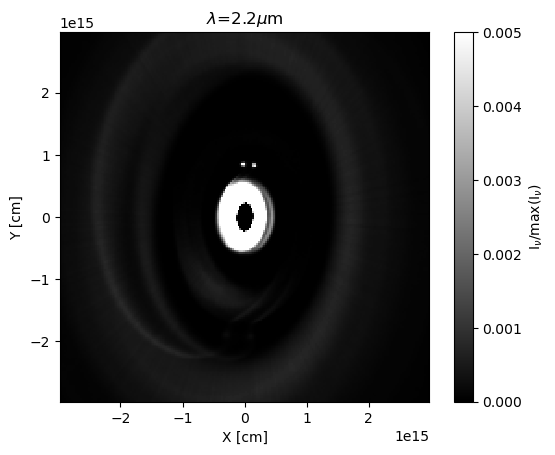

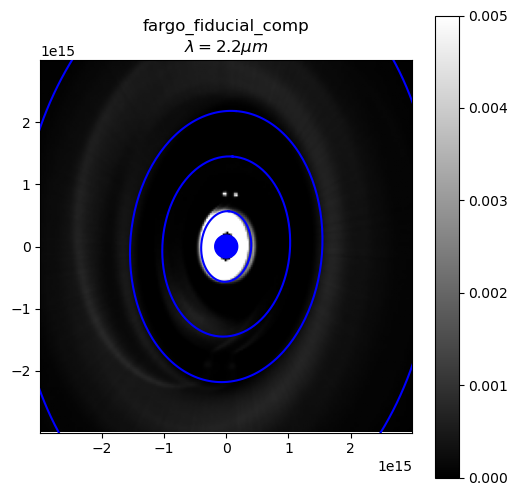

#########################
fargo_fiducial_super_light_comp images:
#########################


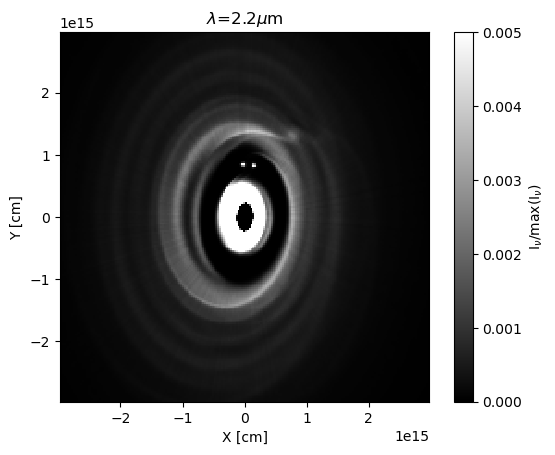

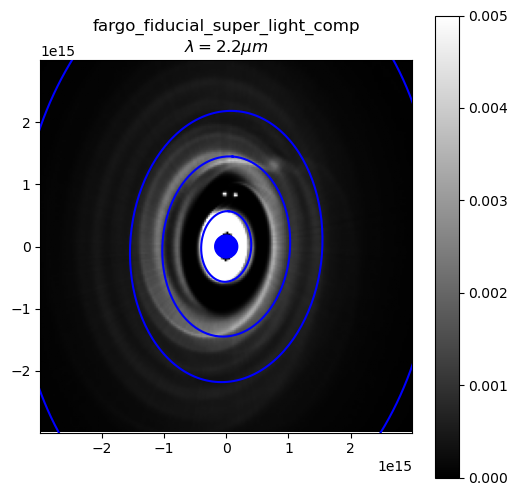

#########################
fargo_fiducial_light_comp images:
#########################


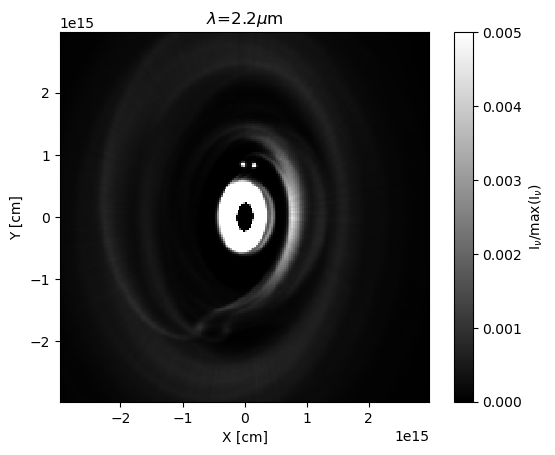

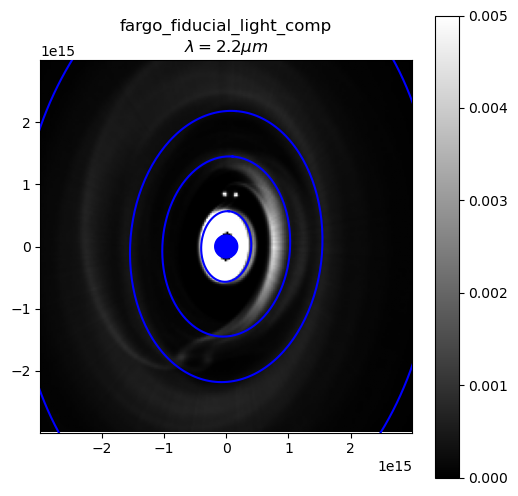

#########################
fargo_fiducial_heavy_comp images:
#########################


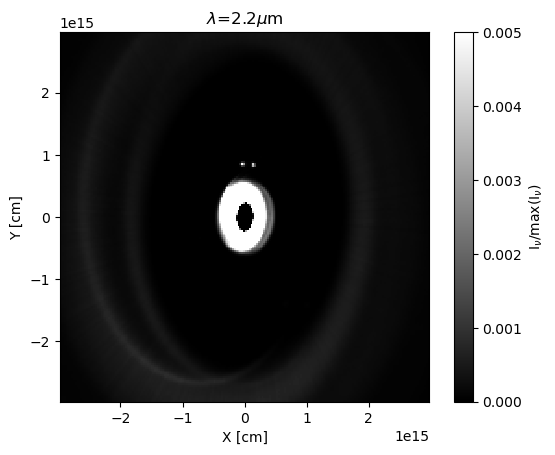

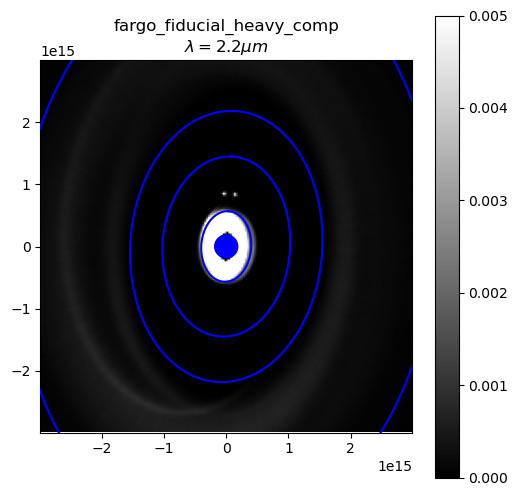

#########################
fargo_fiducial_close_comp images:
#########################


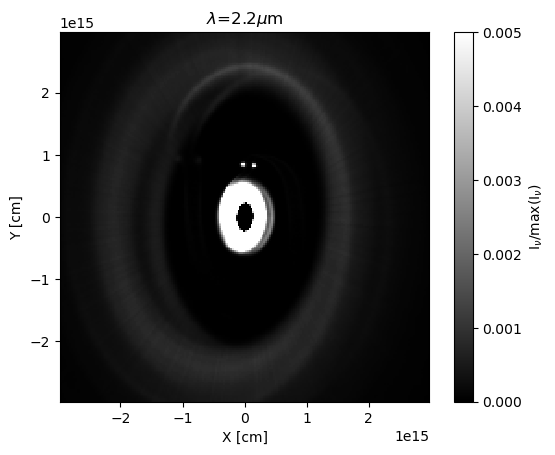

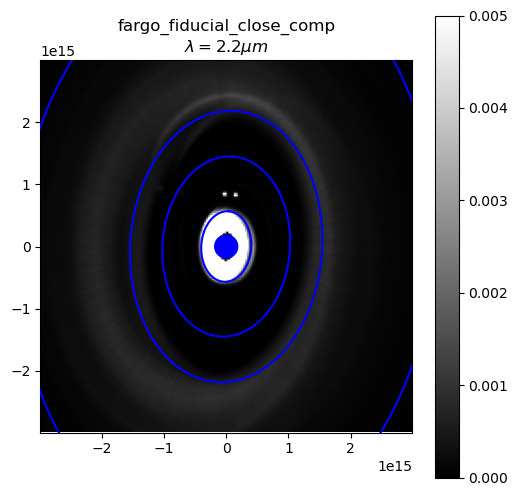

#########################
fargo_fiducial_close_light_comp images:
#########################


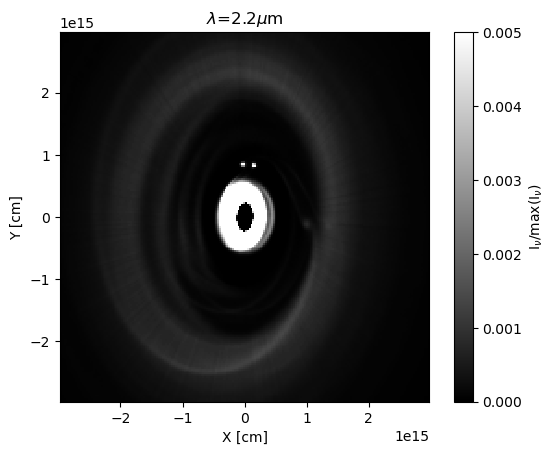

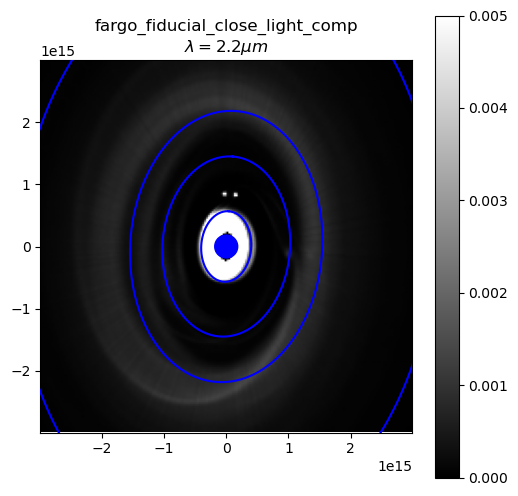

#########################
fargo_fiducial_companion_with_fee images:
#########################


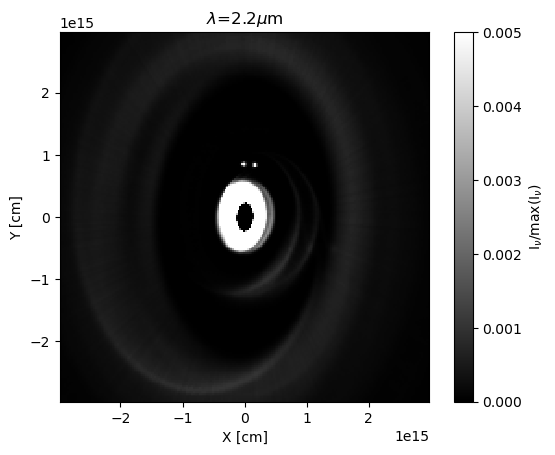

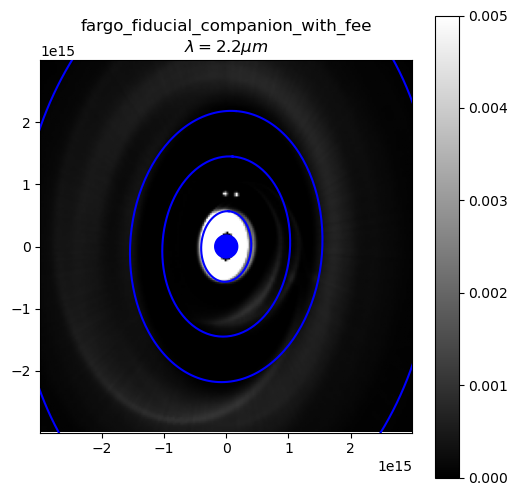

#########################
fargo_fiducial_close_super_light_comp images:
#########################


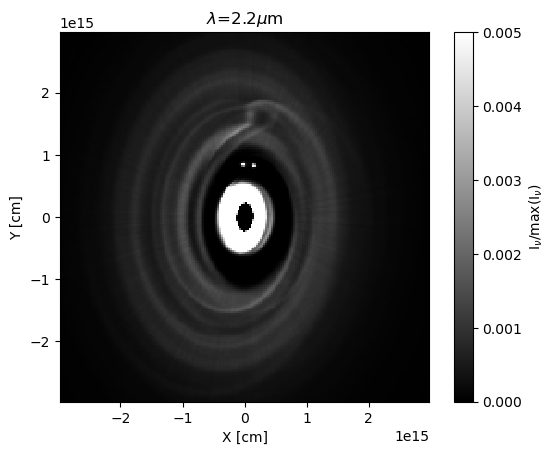

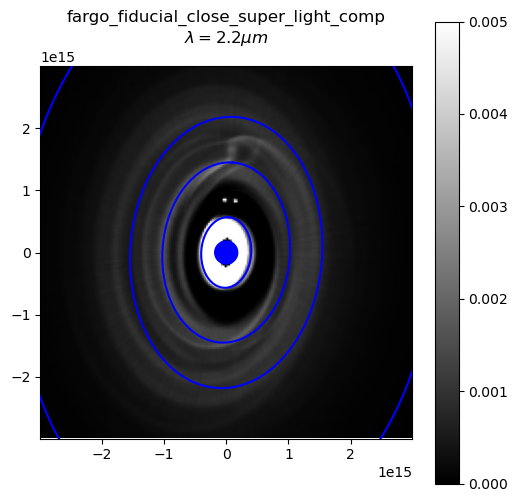

#########################
fargo_fiducial_closer_light_comp images:
#########################


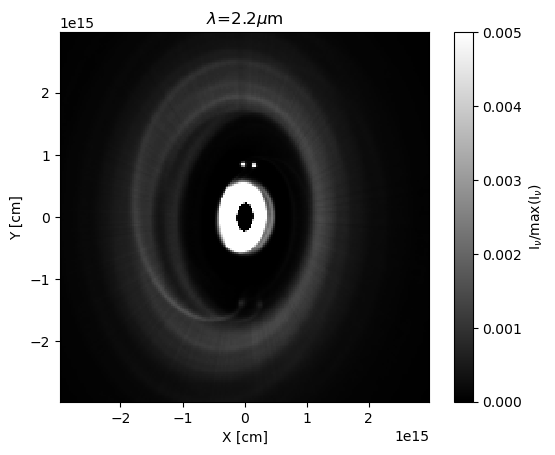

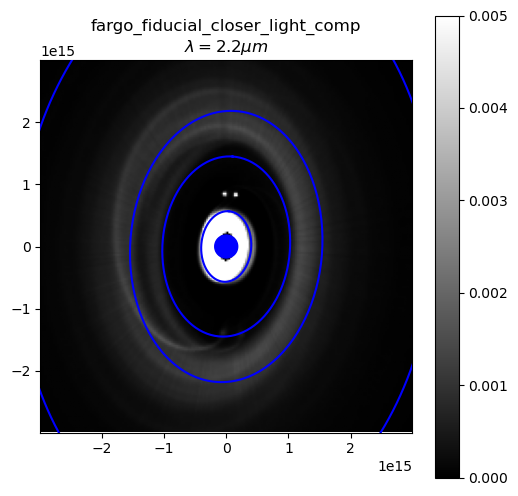

In [12]:
posang = 356+90
sizeau = 400
for i,path in enumerate(paths[:9]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #result = plotImage(images_K[i],log=True, maxlog=10)
    
    result = plotImage(images_K[i],saturate=0.005)#, fig=fig,ax=ax)# showfig=False)
   
    img = result["implot"]
    
    data = img.get_array()
    extent = img.get_extent()
    cmap = img.get_cmap()
    norm = img.norm


    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        data,
        extent=extent,
        cmap=cmap,
        norm=norm,
    )
    
        
    plt.colorbar(ax.images[0], ax=ax)
    plt.title(f"{path[43:-5]}\n$\\lambda = 2.2 \\mu m$")
    plt.savefig(f"img/radmc3d_{path[43:-5]}_scatmode_3.png")

    phi = np.linspace(0,2*np.pi,200)
    posang_rad = (-posang+90)/180*np.pi
    #316, 164, 97, and 38
    au  = 1.49598e13 
    for ri in [38,97,146,316]:
        r = ri*au
        x = r*np.sin(phi)*np.sin(incl/360*2*np.pi)
        y= r*np.cos(phi)

        xx = x*np.cos(posang_rad) + y*np.sin(posang_rad)
        yy = -x*np.sin(posang_rad) + y*np.cos(posang_rad)
        ax.plot(xx, yy, c="blue", zorder=10)

    ## The coronagraph
    r = 185e-3/2*133.3 * au # 185 mas diameter, 133.3 pc distance
    xx = r * np.sin(phi)
    yy = r*np.cos(phi)
    
    ax.fill(xx,yy, c="blue", hatch="/")

    plt.savefig(f"img/radmc3d_{path[43:-5]}_scatmode_3_rings.png")
    plt.xlim(-sizeau/2*au, sizeau/2*au)
    plt.ylim(-sizeau/2*au, sizeau/2*au)
    plt.show()

    
    #print(posang, posang_rad, np.cos(posang_rad))

## Best (for now)

In [ ]:
best =  [7,8,9]
for i in best:
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    result = plotImage(images_K[i],log=True, maxlog=3.4)
    
    result = plotImage(images_K[i],saturate=0.007)#, fig=fig,ax=ax)# showfig=False)
    img = result["implot"]
    plt.savefig(f"img/radmc3d_{path[43:-5]}_scatmode_3.png")
    data = img.get_array()
    extent = img.get_extent()
    cmap = img.get_cmap()
    norm = img.norm


    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        data,
        extent=extent,
        cmap=cmap,
        norm=norm,
    )
    phi = np.linspace(0,2*np.pi,200)
    posang_rad = (-posang+90)/180*np.pi
    #316, 164, 97, and 38
    au  = 1.49598e13 
    for ri in [38,97,146,316]:
        r = ri*au
        x = r*np.sin(phi)*np.sin(incl/360*2*np.pi)
        y= r*np.cos(phi)

        xx = x*np.cos(posang_rad) + y*np.sin(posang_rad)
        yy = -x*np.sin(posang_rad) + y*np.cos(posang_rad)
        ax.plot(xx, yy, c="blue", zorder=10)

    ## The coronagraph
    r = 185e-3/2*133.3 * au # 185 mas diameter, 133.3 pc distance
    xx = r * np.sin(phi)
    yy = r*np.cos(phi)
    ax.fill(xx,yy, c="blue", hatch="/")
    
    plt.colorbar(ax.images[0], ax=ax)
    plt.title(f"{path[43:-5]}\n$\\lambda = 2.2 \\mu m$")
    plt.show()

    plt.savefig(f"img/radmc3d_{path[43:-5]}_scatmode_3_rings.png")
    #print(posang, posang_rad, np.cos(posang_rad))